# COMPARISON OF THE MODELS

In [34]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt

In [35]:
# cartella dove si trovano i csv
base_folder = "/Users/kingsley/Documents/TESI/GITHUB_TESI/gl-forecasting-edge-performance/experiments/11n-8k/seed4850"

In [36]:
# cartella output
output_folder = os.path.join(base_folder, "model_comparison")
os.makedirs(output_folder, exist_ok=True)


In [37]:
# raccolta file all_test_avg_metrics
csv_files = glob.glob(
    os.path.join(base_folder, "all_test_avg_metrics-MergeStrategy.*.csv")
)

all_dfs = []

for file in csv_files:
    
    # nome file
    filename = os.path.basename(file)
    
    # estrai merge strategy
    merge_strategy = (
        filename
        .replace("all_test_avg_metrics-MergeStrategy.", "")
        .replace(".csv", "")
    )
    
    # leggi csv
    df = pd.read_csv(file)
    
    # aggiungi colonna merge strategy
    df["merge_strategy"] = merge_strategy
    
    # append
    all_dfs.append(df)

In [38]:
csv_files

['/Users/kingsley/Documents/TESI/GITHUB_TESI/gl-forecasting-edge-performance/experiments/11n-8k/seed4850/all_test_avg_metrics-MergeStrategy.OVERWRITE.csv',
 '/Users/kingsley/Documents/TESI/GITHUB_TESI/gl-forecasting-edge-performance/experiments/11n-8k/seed4850/all_test_avg_metrics-MergeStrategy.IMPROVED_OVERWRITE.csv',
 '/Users/kingsley/Documents/TESI/GITHUB_TESI/gl-forecasting-edge-performance/experiments/11n-8k/seed4850/all_test_avg_metrics-MergeStrategy.SIMPLE_AVG.csv',
 '/Users/kingsley/Documents/TESI/GITHUB_TESI/gl-forecasting-edge-performance/experiments/11n-8k/seed4850/all_test_avg_metrics-MergeStrategy.AGE_WEIGHTED.csv']

In [39]:
all_dfs

[                  Unnamed: 0       mape       mse        r2  accuracy    seed  \
 0                     single   4.706165  0.009592  0.693543  0.986057     NaN   
 1                centralized   4.125508  0.007159  0.783645  0.980662     NaN   
 2                     gossip   4.315687  0.007815  0.766654  0.983360  8784.0   
 3       single (generalized)  16.560153  0.104984 -1.699568  0.714406     NaN   
 4  centralized (generalized)   4.252582  0.007337  0.811345  0.975202     NaN   
 5       gossip (generalized)  21.452320  0.245153 -5.303865  0.669902  8784.0   
 
    idx merge_strategy  
 0    0      OVERWRITE  
 1    0      OVERWRITE  
 2    0      OVERWRITE  
 3    0      OVERWRITE  
 4    0      OVERWRITE  
 5    0      OVERWRITE  ,
                   Unnamed: 0       mape       mse        r2  accuracy    seed  \
 0                     single   4.706165  0.009592  0.693543  0.986057     NaN   
 1                centralized   4.125508  0.007159  0.783645  0.980662     NaN   
 2

In [40]:
final_df = pd.concat(all_dfs, ignore_index=True)

In [41]:
# salva
output_file = os.path.join(output_folder, "all_model_comparison.csv")
final_df.to_csv(output_file, index=False)

print(f"File salvato in:\n{output_file}")

File salvato in:
/Users/kingsley/Documents/TESI/GITHUB_TESI/gl-forecasting-edge-performance/experiments/11n-8k/seed4850/model_comparison/all_model_comparison.csv


# COMPARISON

In [42]:
file_path = "/Users/kingsley/Documents/TESI/GITHUB_TESI/gl-forecasting-edge-performance/experiments/11n-8k/seed4850/model_comparison/all_model_comparison.csv"

df = pd.read_csv(file_path)

df = df.rename(columns={"Unnamed: 0": "model"})

df.head()

,model,mape,mse,r2,accuracy,seed,idx,merge_strategy
0,single,4.706165,0.009592,0.693543,0.986057,NaN,0,OVERWRITE
1,centralized,4.125508,0.007159,0.783645,0.980662,NaN,0,OVERWRITE
2,gossip,4.315687,0.007815,0.766654,0.983360,8784.0,0,OVERWRITE
3,single (generalized),16.560153,0.104984,-1.699568,0.714406,NaN,0,OVERWRITE
4,centralized (generalized),4.252582,0.007337,0.811345,0.975202,NaN,0,OVERWRITE


In [43]:
normal_df = df[df["model"].isin(["single", "centralized", "gossip"])].copy()

generalized_df = df[df["model"].isin([
    "single (generalized)",
    "centralized (generalized)",
    "gossip (generalized)"
])].copy()

normal_df.head()

,model,mape,mse,r2,accuracy,seed,idx,merge_strategy
0,single,4.706165,0.009592,0.693543,0.986057,NaN,0,OVERWRITE
1,centralized,4.125508,0.007159,0.783645,0.980662,NaN,0,OVERWRITE
2,gossip,4.315687,0.007815,0.766654,0.983360,8784.0,0,OVERWRITE
6,single,4.706165,0.009592,0.693543,0.986057,NaN,0,IMPROVED_OVERWRITE
7,centralized,4.125508,0.007159,0.783645,0.980662,NaN,0,IMPROVED_OVERWRITE


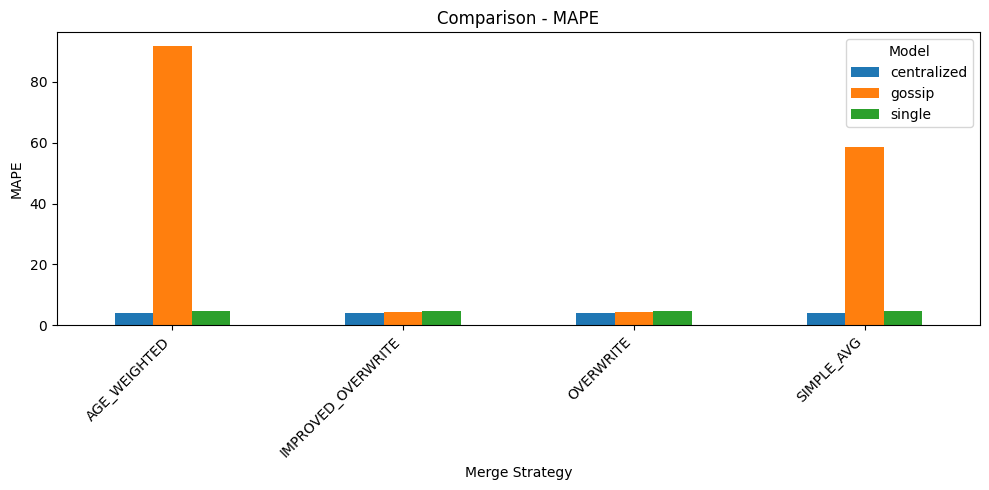

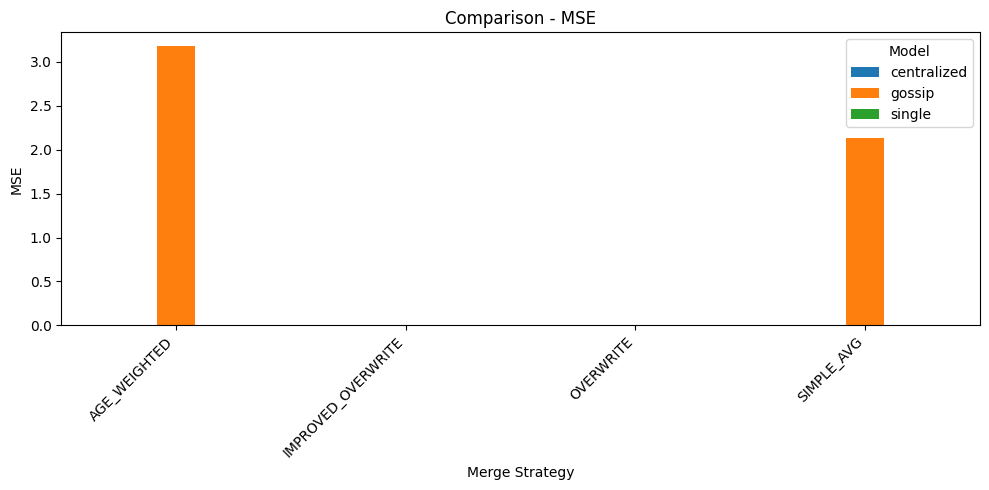

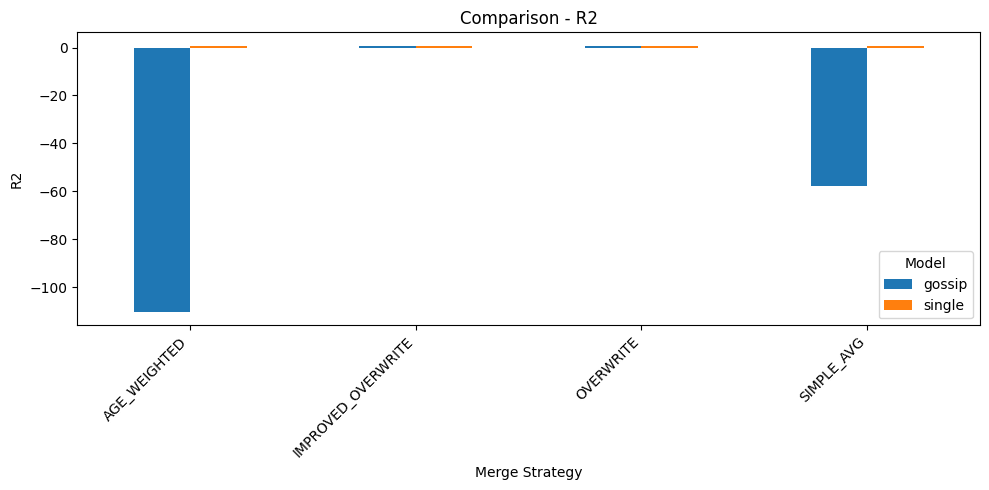

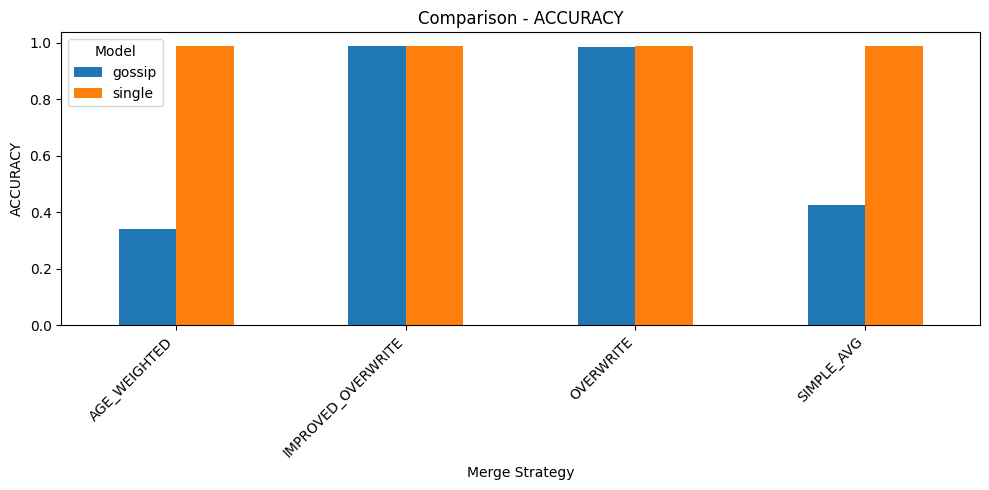

In [44]:
metrics = ["mape", "mse", "r2", "accuracy"]

for metric in metrics:
    
    plot_df = normal_df.copy()
    
    # per r2 e accuracy considera solo single e gossip
    if metric in ["r2", "accuracy"]:
        plot_df = plot_df[plot_df["model"].isin(["single", "gossip"])]
    
    pivot_df = plot_df.pivot(
        index="merge_strategy",
        columns="model",
        values=metric
    )
    
    ax = pivot_df.plot(kind="bar", figsize=(10, 5))
    
    plt.title(f"Comparison - {metric.upper()}")
    plt.xlabel("Merge Strategy")
    plt.ylabel(metric.upper())
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

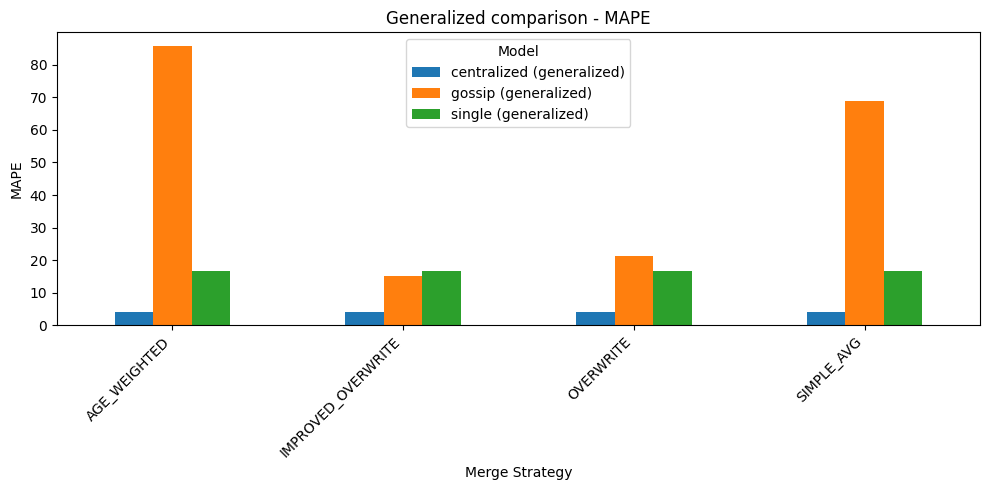

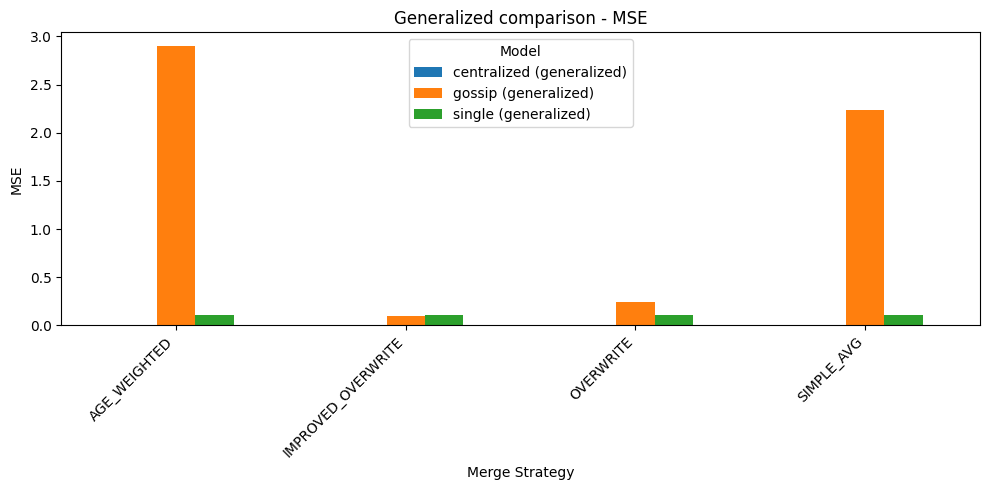

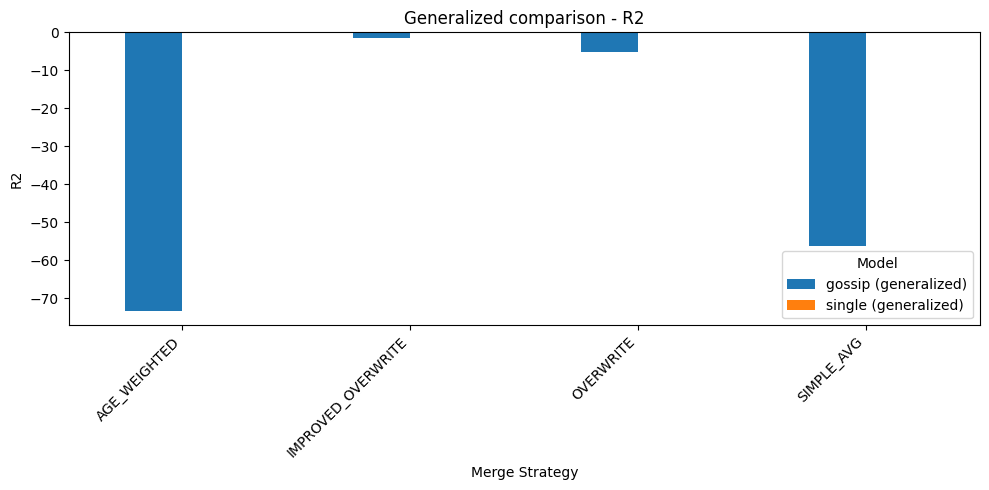

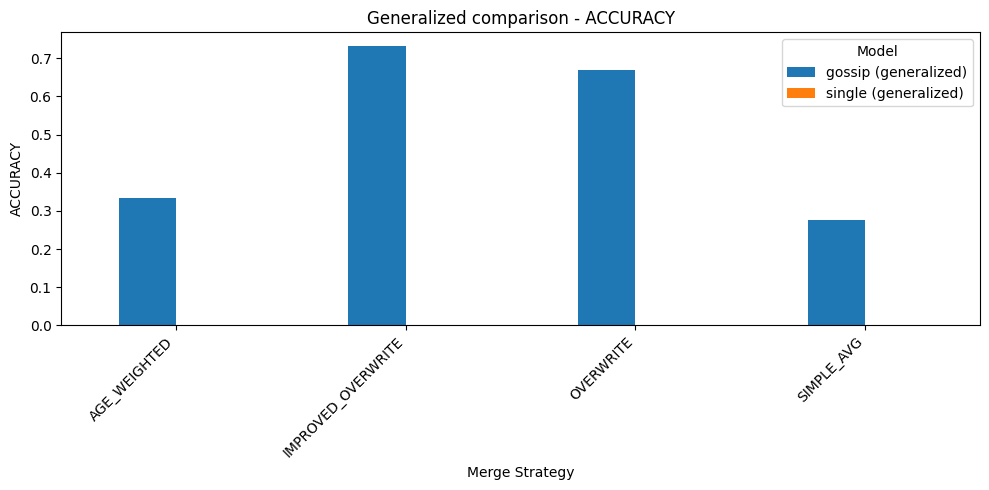

In [29]:
metrics = ["mape", "mse", "r2", "accuracy"]

for metric in metrics:
    
    plot_df = generalized_df.copy()
    
    # per r2 e accuracy considera solo single generalized e gossip generalized
    if metric in ["r2", "accuracy"]:
        plot_df = plot_df[plot_df["model"].isin([
            "single (generalized)",
            "gossip (generalized)"
        ])]
    
    pivot_df = plot_df.pivot(
        index="merge_strategy",
        columns="model",
        values=metric
    )
    
    ax = pivot_df.plot(kind="bar", figsize=(10, 5))
    
    plt.title(f"Generalized comparison - {metric.upper()}")
    plt.xlabel("Merge Strategy")
    plt.ylabel(metric.upper())
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Model")
    plt.tight_layout()
    plt.show()

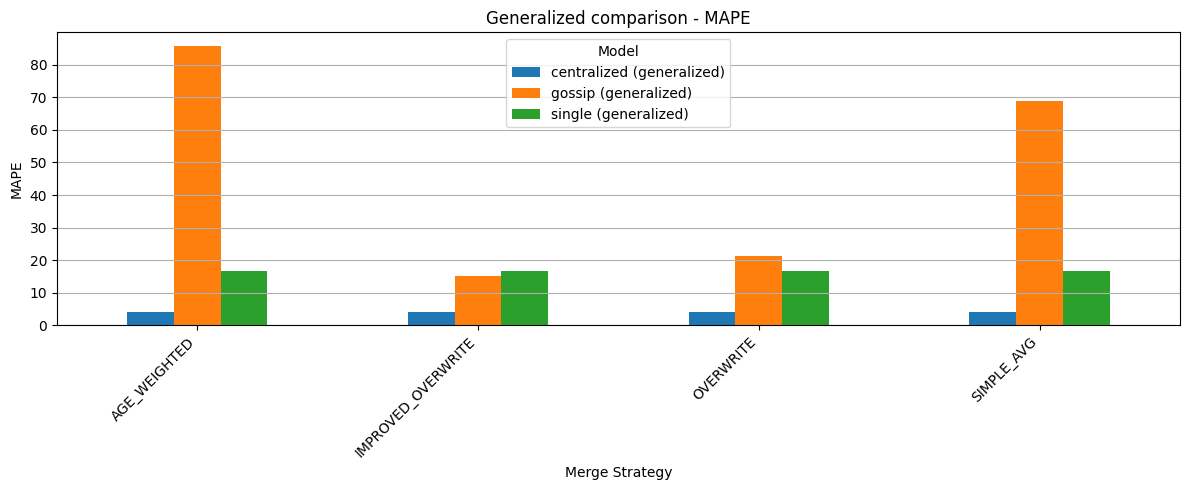

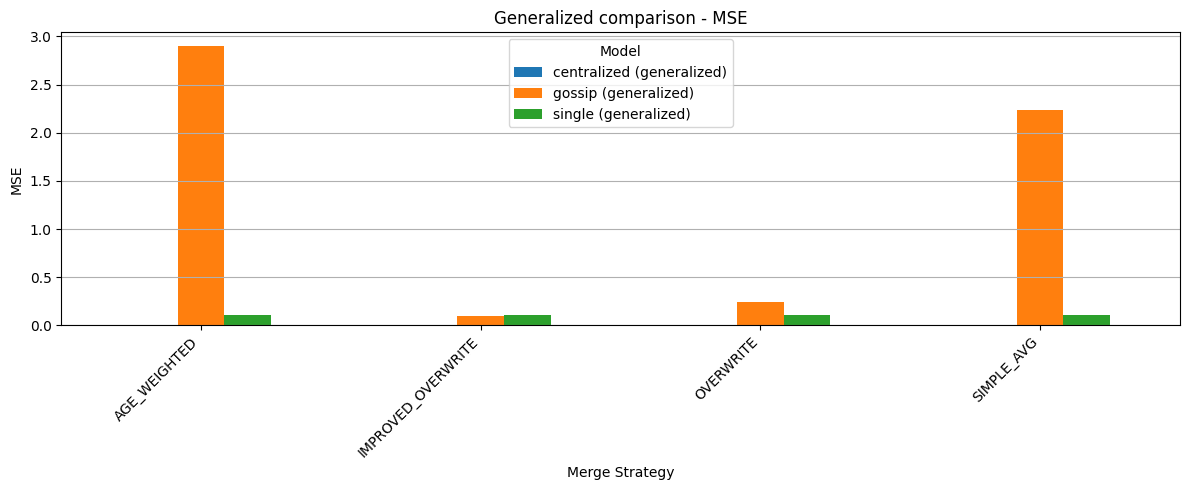

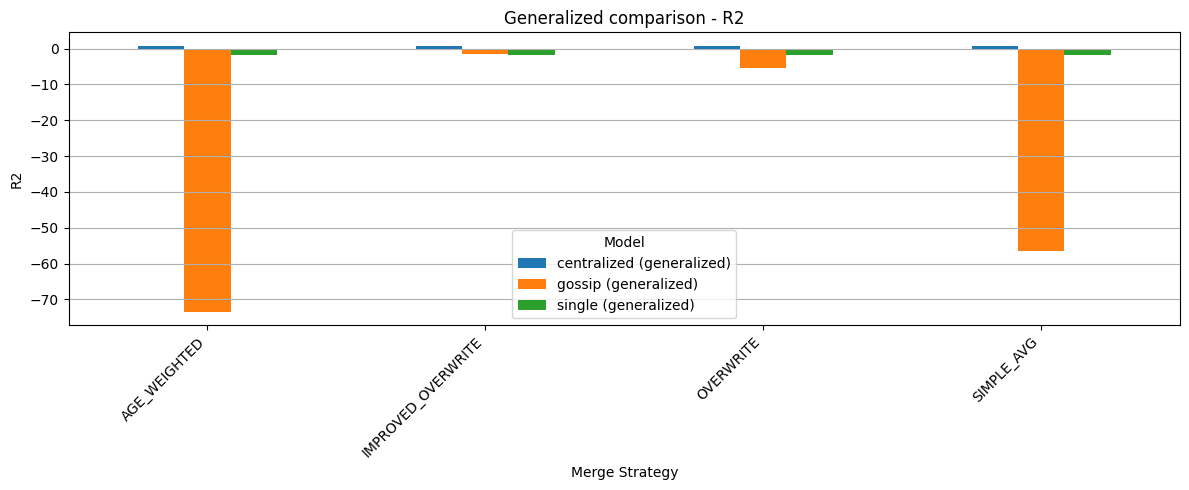

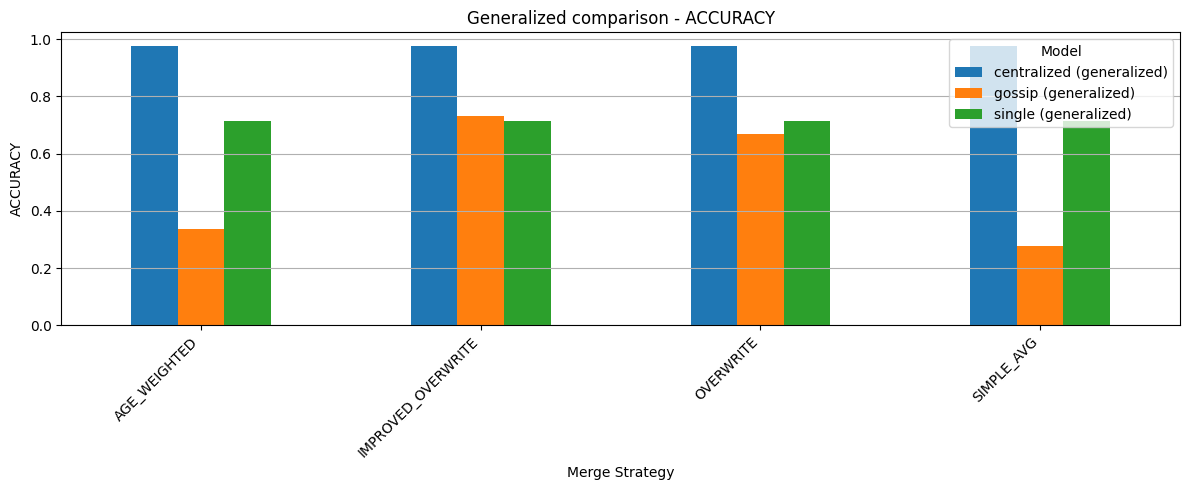

In [45]:
metrics = ["mape", "mse", "r2", "accuracy"]

for metric in metrics:
    
    plot_df = generalized_df.copy()
    
    # per generalized:
    # centralized generalized non ha gossip classification in alcuni casi
    # quindi per sicurezza filtra solo righe non NaN
    if metric in ["r2", "accuracy"]:
        plot_df = plot_df.dropna(subset=[metric])
    
    pivot_df = plot_df.pivot(
        index="merge_strategy",
        columns="model",
        values=metric
    )
    
    ax = pivot_df.plot(
        kind="bar",
        figsize=(12, 5)
    )
    
    plt.title(f"Generalized comparison - {metric.upper()}")
    plt.xlabel("Merge Strategy")
    plt.ylabel(metric.upper())
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Model")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

# ALTRE TABELLE

In [30]:
def get_best_models(data, metrics):
    results = []

    for metric in metrics:
        temp = data.dropna(subset=[metric]).copy()

        if temp.empty:
            continue

        if metric in ["mape", "mse"]:
            best_row = temp.loc[temp[metric].idxmin()]
            direction = "LOWER is better"
        else:
            best_row = temp.loc[temp[metric].idxmax()]
            direction = "HIGHER is better"

        results.append({
            "metric": metric,
            "best_model": best_row["model"],
            "merge_strategy": best_row["merge_strategy"],
            "best_value": best_row[metric],
            "direction": direction
        })

    return pd.DataFrame(results)

In [31]:
metrics = ["mape", "mse", "r2", "accuracy"]

best_normal = get_best_models(normal_df, metrics)
best_normal

,metric,best_model,merge_strategy,best_value,direction
0,mape,centralized,OVERWRITE,4.125508,LOWER is better
1,mse,centralized,OVERWRITE,0.007159,LOWER is better
2,r2,gossip,IMPROVED_OVERWRITE,0.769929,HIGHER is better
3,accuracy,gossip,IMPROVED_OVERWRITE,0.986728,HIGHER is better


In [32]:
metrics = ["mape", "mse", "r2", "accuracy"]

for metric in metrics:

    print("\n")
    print("=" * 80)
    print(f"CLASSIFICA NORMAL - {metric.upper()}")
    print("=" * 80)

    ranking_df = normal_df.dropna(subset=[metric]).copy()

    ranking_df["full_model"] = (
        ranking_df["model"] + " | " + ranking_df["merge_strategy"]
    )

    # MAPE e MSE: più basso = meglio
    ascending = metric in ["mape", "mse"]

    ranking_df = ranking_df.sort_values(
        metric,
        ascending=ascending
    )

    display(
        ranking_df[
            ["full_model", metric]
        ].reset_index(drop=True)
    )



CLASSIFICA NORMAL - MAPE


,full_model,mape
0,centralized | OVERWRITE,4.125508
1,centralized | IMPROVED_OVERWRITE,4.125508
2,centralized | SIMPLE_AVG,4.125508
3,centralized | AGE_WEIGHTED,4.125508
4,gossip | IMPROVED_OVERWRITE,4.272338
5,gossip | OVERWRITE,4.315687
6,single | OVERWRITE,4.706165
7,single | IMPROVED_OVERWRITE,4.706165
8,single | SIMPLE_AVG,4.706165
9,single | AGE_WEIGHTED,4.706165




CLASSIFICA NORMAL - MSE


,full_model,mse
0,centralized | OVERWRITE,0.007159
1,centralized | SIMPLE_AVG,0.007159
2,centralized | AGE_WEIGHTED,0.007159
3,centralized | IMPROVED_OVERWRITE,0.007159
4,gossip | IMPROVED_OVERWRITE,0.007700
5,gossip | OVERWRITE,0.007815
6,single | OVERWRITE,0.009592
7,single | IMPROVED_OVERWRITE,0.009592
8,single | SIMPLE_AVG,0.009592
9,single | AGE_WEIGHTED,0.009592




CLASSIFICA NORMAL - R2


,full_model,r2
0,gossip | IMPROVED_OVERWRITE,0.769929
1,gossip | OVERWRITE,0.766654
2,single | OVERWRITE,0.693543
3,single | IMPROVED_OVERWRITE,0.693543
4,single | SIMPLE_AVG,0.693543
5,single | AGE_WEIGHTED,0.693543
6,gossip | SIMPLE_AVG,-57.738206
7,gossip | AGE_WEIGHTED,-110.257380




CLASSIFICA NORMAL - ACCURACY


,full_model,accuracy
0,gossip | IMPROVED_OVERWRITE,0.986728
1,single | OVERWRITE,0.986057
2,single | IMPROVED_OVERWRITE,0.986057
3,single | SIMPLE_AVG,0.986057
4,single | AGE_WEIGHTED,0.986057
5,gossip | OVERWRITE,0.983360
6,gossip | SIMPLE_AVG,0.425916
7,gossip | AGE_WEIGHTED,0.340457


In [33]:
metrics = ["mape", "mse", "r2", "accuracy"]

for metric in metrics:

    print("\n")
    print("=" * 80)
    print(f"CLASSIFICA GENERALIZED - {metric.upper()}")
    print("=" * 80)

    ranking_df = generalized_df.dropna(subset=[metric]).copy()

    ranking_df["full_model"] = (
        ranking_df["model"] + " | " + ranking_df["merge_strategy"]
    )

    # MAPE e MSE: più basso = meglio
    ascending = metric in ["mape", "mse"]

    ranking_df = ranking_df.sort_values(
        metric,
        ascending=ascending
    )

    display(
        ranking_df[
            ["full_model", metric]
        ].reset_index(drop=True)
    )



CLASSIFICA GENERALIZED - MAPE


,full_model,mape
0,centralized (generalized) | OVERWRITE,4.252582
1,centralized (generalized) | IMPROVED_OVERWRITE,4.252582
2,centralized (generalized) | SIMPLE_AVG,4.252582
3,centralized (generalized) | AGE_WEIGHTED,4.252582
4,gossip (generalized) | IMPROVED_OVERWRITE,15.242191
5,single (generalized) | OVERWRITE,16.560153
6,single (generalized) | IMPROVED_OVERWRITE,16.560153
7,single (generalized) | SIMPLE_AVG,16.560153
8,single (generalized) | AGE_WEIGHTED,16.560153
9,gossip (generalized) | OVERWRITE,21.452320




CLASSIFICA GENERALIZED - MSE


,full_model,mse
0,centralized (generalized) | OVERWRITE,0.007337
1,centralized (generalized) | IMPROVED_OVERWRITE,0.007337
2,centralized (generalized) | SIMPLE_AVG,0.007337
3,centralized (generalized) | AGE_WEIGHTED,0.007337
4,gossip (generalized) | IMPROVED_OVERWRITE,0.096678
5,single (generalized) | OVERWRITE,0.104984
6,single (generalized) | IMPROVED_OVERWRITE,0.104984
7,single (generalized) | SIMPLE_AVG,0.104984
8,single (generalized) | AGE_WEIGHTED,0.104984
9,gossip (generalized) | OVERWRITE,0.245153




CLASSIFICA GENERALIZED - R2


,full_model,r2
0,gossip (generalized) | IMPROVED_OVERWRITE,-1.485989
1,gossip (generalized) | OVERWRITE,-5.303865
2,gossip (generalized) | SIMPLE_AVG,-56.390450
3,gossip (generalized) | AGE_WEIGHTED,-73.518082




CLASSIFICA GENERALIZED - ACCURACY


,full_model,accuracy
0,gossip (generalized) | IMPROVED_OVERWRITE,0.731551
1,gossip (generalized) | OVERWRITE,0.669902
2,gossip (generalized) | AGE_WEIGHTED,0.335158
3,gossip (generalized) | SIMPLE_AVG,0.276362
